# Purpose / Outline
- Load simulation data generated by 
- Plot maps of energy burdens 
- 

In [1]:
import geopandas as gpd
import numpy as np
import matplotlib
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import matplotlib.colors as colors 
import contextily as cx
import textwrap
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

def plot_df(simulation_results, column, vmin, vmax, label, title, cbar=False, save=False, save_dir = None):
    # discretize the color map for the scatter plot
    discrete_list = [val for val in range(12)]
    discrete_list = [val/max(discrete_list) for val in discrete_list]
    
    scatter_cmap = colors.ListedColormap(matplotlib.colormaps['seismic'](discrete_list))  
    geomap_cmap = matplotlib.colormaps['Pastel2']

    fig, ax = plt.subplots()

    ax.set_xlim(-126, -65)
    ax.set_ylim(24, 50)
    ax.set_aspect('equal')

    gdf.plot(ax=ax, 
             column='BA_Climate', 
             cmap=geomap_cmap, 
             alpha=0.75, 
             legend=False, 
            #  legend_kwds={"ncols": 4, "loc": "lower center", "bbox_to_anchor": (0.5, -0.2)},
        )
        
    # state_shapes.boundary.plot()
    state_shapes.plot(ax=ax, facecolor="none", edgecolor='black', linewidth=0.05)

    # Plot the Pandas DataFrame as points
    plt.scatter(simulation_results['in.weather_file_longitude'], 
                simulation_results['in.weather_file_latitude'], 
                c=simulation_results[column] * 100,  # multiple by 100 to convert from fractional to percent 
                vmin= vmin * 100,
                vmax= vmax * 100,
                cmap=scatter_cmap, 
                edgecolors='black',
                linewidths=0.5,
                s = 60,  #marker size
                marker='o', 
                alpha=1)
        
    print(simulation_results[simulation_results[column] == simulation_results[column].max()])
    print(simulation_results[simulation_results[column] == simulation_results[column].min()])

    if cbar: 
        cb=plt.colorbar(label=label, orientation="vertical", fraction=0.016, pad=0.04)
        cb.outline.set_color('white')
        cb.outline.set_linewidth(2)
        cb.set_label(label=textwrap.fill(label, width=40) , size=10, weight='bold')  # split the colorbar label into mulitple lines to ensure it doesn't widen the figure

    # cb.dividers.set_color('white')
    # cb.dividers.set_linewidth(2)

    plt.title(textwrap.fill(title, width=30), fontsize=15, fontweight='bold')  # split the title into multiple lines to ensure it doesn't widen the figure
    plt.axis('off')
    # plt.tight_layout()
    plt.show()

    if save: fig.savefig(Path(save_dir, title + '.png'), dpi=1200, bbox_inches='tight')


def join_historical_data_alongside_future(i_df, join_cols):
    if len(i_df) != len(i_df.drop_duplicates()): raise RuntimeError('Duplicate rows in input dataframe')

    base_df = i_df[ i_df['CONUS Annual Climate Change Bins [Celsius]'] == 'Historical' ].copy(deep=True).reset_index(drop=True)

    i_df = pd.merge(i_df, base_df, on=join_cols, how='left', suffixes=['', '_r'], left_index=False, right_index=False, sort=False, validate="many_to_one")#.reset_index()   # merge the base results onto the rhs to ensure the data is aligned for differencing. Make sure the right dataset merge keys are unique
        
    if len(i_df) != len(i_df): raise RuntimeError('Dataframe length changed during merging')

    return i_df


def take_differences(i_df, columns_2_difference):

    difference_columns = ['Change in ' + column for column in columns_2_difference]
    frac_diff_columns = ['Percent Change in ' + column for column in columns_2_difference]

    # Calculate differences
    base_columns_2_difference = [col + '_r' for col in columns_2_difference]
    
    for i in range(len(columns_2_difference)): 
        i_df[frac_diff_columns[i]] = (i_df[columns_2_difference[i]] - i_df[base_columns_2_difference[i]]) / i_df[base_columns_2_difference[i]]
    
    for i in range(len(columns_2_difference)): 
        i_df[difference_columns[i]] = i_df[columns_2_difference[i]] - i_df[base_columns_2_difference[i]]

    # i_df = i_df.drop(i_df.filter(regex='_r$').columns, axis=1)  # https://stackoverflow.com/questions/19125091/pandas-merge-how-to-avoid-duplicating-columns

    return i_df


def calculate_nrg_burden_exceedance_percentage(df, threshold_value_1, threshold_value_2, group_by_cols):
    """
    Calculates the percentage of entries for each unique metadata grouping
    where the 'Energy Burden' exceeds the specified threshold value.

    Args:
        df: The pandas DataFrame containing the data.
        threshold_value: The threshold value for the 'Energy Burden'.

    Returns:
        A pandas DataFrame with unique metadata groupings and their corresponding percentages.
    """

    # Filter rows where 'Energy Burden' exceeds the threshold
    filtered_df_1 = df[df['Energy Burden'] > threshold_value_1]
    filtered_df_2 = df[df['Energy Burden'] > threshold_value_2]

    # Group by metadata columns and count entries
    grouped_counts_1 = filtered_df_1.groupby(group_by_cols).size().reset_index(name='count_1')
    grouped_counts_2 = filtered_df_2.groupby(group_by_cols).size().reset_index(name='count_2')

    # Group original DataFrame by metadata columns and count total entries
    total_counts = df.groupby(group_by_cols).size().reset_index(name='total')

    # Merge grouped counts and total counts
    merged_df = pd.merge(total_counts, grouped_counts_1, on= group_by_cols, how="left").fillna(0)
    merged_df2 = pd.merge(merged_df, grouped_counts_2, on= group_by_cols, how="left").fillna(0)

    # Calculate fraaction of time that the percentages of energy burden are exceeded
    merged_df2['6pp Exceedance'] = (merged_df2['count_1'] / merged_df2['total'])
    merged_df2['10pp Exceedance'] = (merged_df2['count_2'] / merged_df2['total'])

    if len(merged_df2) != 4*3*len(df['bldg_id'].unique()): 
        print("len(merged_df2)", len(merged_df2))
        print("len(df['bldg_id'].unique()", 4*3*len(df['bldg_id'].unique()))
        raise RuntimeError()

    return merged_df2.reset_index(drop=True)


def sum_energy_metrics(simulation_results, groupby_cols, columns_to_sum, no_months_per_period):
    # calculate the aggregated annual results 
    annual_results = simulation_results.groupby(groupby_cols)[columns_to_sum].sum().reset_index()
    annual_results['Energy Burden [Monthly]'] = annual_results['Cost Energy:Facility [$](Monthly)'] / (annual_results['Income - High [Annual]'] * ( no_months_per_period / 12) )
    return annual_results


def calculate_percentiles(df, percentiles, groupby_cols, data_cols):

    percentile_dataframes = []
    for percentile in percentiles: 
        percentile_data = df.groupby(groupby_cols)[data_cols].quantile(percentile).reset_index()   # calculate the percentiles 
        percentile_data['Percentile'] = percentile  # record which percentile was calculated 
        percentile_dataframes.append(percentile_data)

    percentile_data = pd.concat(percentile_dataframes, ignore_index=True)   # join all the calculated percentiles into one longer table 

    return percentile_data


def replace_column_name_text(df, old_text, new_text):
    df_columns_renaming = {col: col.replace(old_text, new_text) for col in df.columns if old_text in col}
    df = df.rename(columns= df_columns_renaming, errors="raise")
    return df


def join_metadata(df, metadata, on_and_groupby_cols, data_col_check):
    len1 = len(df)
    data = df[data_col_check].copy(deep=True)
    df = pd.merge(df, metadata, how='inner', on=on_and_groupby_cols, suffixes=['', '_r'], left_index=False, 
                  right_index=False, sort=False).groupby(on_and_groupby_cols, as_index=False).first()
    
    if len(df) != len1: raise RuntimeError(len1, len(df))
    if (data != df[data_col_check]).any(): raise RuntimeError('Data changed during merging on metadata')
    df = df.drop(df.filter(regex='_r$').columns, axis=1)  # https://stackoverflow.com/questions/19125091/pandas-merge-how-to-avoid-duplicating-columns
    return df 


def find_abs_max(df_dictionary, col_name_fragment):
    abs_max = 0
    for key, value in df_dictionary.items():
        abs_max = max([abs_max, value[[col for col in value.columns if col_name_fragment in col][0]].abs().max()])

    return abs_max


def plot_df_dictionary(dictionary, col_name_fragment, label, save, cbar, save_dir):
    dic_items_list = list(dictionary.items())

    for key, value in dictionary.items():
        if key != 'abs_max':
            if dic_items_list[-2][0] == key:  cbar = True   # if its the second to last item (last item is just the abs_max), add a color bar
            
            plot_df(simulation_results=value , column=[col for col in value.columns if col_name_fragment in col][0], vmin= -dictionary['abs_max'], vmax= dictionary['abs_max'], label=label, title=key, save=save, cbar=cbar, save_dir=save_dir)


def tabulate(df_dict, partial_data_col_name, col_suffix):
    # tabulate the results for exporting
    table = pd.DataFrame()
    table = df_dict[list(df_dict.keys())[0]][['State', 'City', 'Building America Climate Zone']]

    for key, df in df_dict.items():
        if isinstance(df, pd.DataFrame):

            col = [col for col in df.columns if partial_data_col_name in col][0]
            key = key + col_suffix
            df_columns_renaming = {col: key}
            df.rename(columns = df_columns_renaming, inplace=True)
            df[key] = df[key]*100
            table = pd.merge(table, df[['City', key]], on=['City'], how='left', suffixes=['', '_r'], left_index=False, right_index=False, sort=False)#.reset_index()   # merge the base results onto the rhs to ensure the data is aligned for differencing. Make sure the right dataset merge keys are unique
    return table

# Load the data and do some minor pre-processing

In [2]:
gdf = gpd.read_file(Path('/Users/camilotoruno/My Drive/Knowledge & Skills/UMichigan/Research/Energy Burdens/Data & analysis/GIS Data/BA_Climate_Zones_Dissolved_Multipart_Features/DissolvedFeatures.shp'))
state_shapes = gpd.read_file(Path('/Users/camilotoruno/My Drive/Knowledge & Skills/UMichigan/Research/Energy Burdens/Data & analysis/GIS Data/States_shapefile-shp/States_shapefile.shp'))
state_shapes = state_shapes.to_crs(gdf.crs)

# gdf = gdf.to_crs(epsg=4326)   # ensure the coordinate system is correct

# load the simulation results and do some basic operations needed for processing 
simulation_results = pd.read_csv(Path("/Users/camilotoruno/Documents/local_research_data/simulations 24.08.12/results_old_method/simulations_results.csv"))
simulation_results[["Income - Low [Annual]", "Income - High [Annual]"]] = simulation_results["Income"].str.split(expand=True, pat='[-<>]').replace('', 0).astype(int) 
conus_annual_cc_bins = pd.IntervalIndex.from_tuples([(1, 1.5), (1.5, 2), (2, 2.5)])
simulation_results['CONUS Annual Climate Change Bins [Celsius]'] = pd.cut(simulation_results['CONUS Annual Climate Change [Celsius]'], bins=conus_annual_cc_bins).astype(str).replace("nan", "Historical")
simulation_results['Year Index'] = simulation_results['Year'].apply(lambda x: x - 1980 if x < 2020 else x - 2020)  # index future and historic years to same range [0, 39]

/var/folders/_y/4mxb3fn133zdycdh3jhdzvc00000gn/T/ipykernel_3867/2759262784.py:8: DtypeWarning: Columns (19) have mixed types. Specify dtype option on import or set low_memory=False.
  simulation_results = pd.read_csv(Path("/Users/camilotoruno/Documents/local_research_data/simulations 24.08.12/results_old_method/simulations_results.csv"))


# Calculate chronological differences in energy metrics 

### annual burdens & changes (chronologically)

In [3]:
# metadata_cols = [
#     'bldg_id',
#     'Year',
#     'Year Index',
#     'Climate Change Scenario',
#     'CONUS Annual Climate Change Bins [Celsius]',
    
#     'Building America Climate Zone',
#     'City',
#     'Federal Poverty Level',
#     'RECS Building Type',
#     'Heating Fuel',
#     'HVAC Cooling Type',
#     'Infiltration',
#     'State',
#     'in.tenure',
#     'in.weather_file_latitude',
#     'in.weather_file_longitude',
#     'Income',
#     'Income - High [Annual]',
#     'Income per Occupant -  High [Annual]',
#     'Income - Low [Annual]',
#     ]

# columns_to_sum = [
#     'Total Energy Usage:Heating [kWh](Monthly)',
#     'Total Energy Usage:Cooling [kWh](Monthly)',
#     'Total Energy Usage:Space Conditioning [kWh](Monthly)',
#     'Total Energy Usage:Facility [kWh](Monthly)',
#     'Cost Energy:Facility [$](Monthly)',
#     ]

# groupby_cols = [
#     'bldg_id',
#     'Year Index',
#     'Climate Change Scenario',                      # include to ensure chronological differences 
#     'CONUS Annual Climate Change Bins [Celsius]',  # needed for join_historical_data_alongside_future()
#     'Income - High [Annual]',   # needed for energy burden calculation 
#     ]

# annual_results = sum_energy_metrics(simulation_results.copy(deep=True), groupby_cols, columns_to_sum, no_months_per_period = 12)
# annual_results = join_historical_data_alongside_future(i_df = annual_results, join_cols= ['bldg_id', 'Year Index'])
# annual_results = take_differences(annual_results, columns_to_sum + ['Energy Burden [Monthly]'])
# annual_results = join_metadata(df = annual_results, metadata= simulation_results[metadata_cols], 
#                                on_and_groupby_cols = groupby_cols, data_col_check = 'Energy Burden [Monthly]')
# annual_results = replace_column_name_text(annual_results, old_text="Monthly", new_text="Annual")
# annual_results = annual_results.drop(annual_results.filter(regex='_r$').columns, axis=1)  # Drop joined on (duplicated) historical columns used for differencing (_r) columns https://stackoverflow.com/questions/19125091/pandas-merge-how-to-avoid-duplicating-columns


### seasonal burdens & changes (chronologically)

In [4]:
# seas_res = sum_energy_metrics(simulation_results.copy(deep=True), groupby_cols + ['Season'], columns_to_sum, no_months_per_period = 4)
# seas_res = join_historical_data_alongside_future(i_df = seas_res, join_cols= ['bldg_id', 'Year Index', 'Season'])
# seas_res = take_differences(seas_res, columns_to_sum + ['Energy Burden [Monthly]'])
# seas_res = join_metadata(df = seas_res, metadata= simulation_results[metadata_cols + ['Season']],
#                          on_and_groupby_cols= groupby_cols + ['Season'], data_col_check = 'Energy Burden [Monthly]')
# seas_res = replace_column_name_text(seas_res, old_text="Monthly", new_text="Seasonal")
# seas_res = seas_res.drop(seas_res.filter(regex='_r$').columns, axis=1)  # Drop joined on (duplicated) historical columns used for differencing (_r) columns https://stackoverflow.com/questions/19125091/pandas-merge-how-to-avoid-duplicating-columns


In [ ]:
# annual_results['Heating Fuel'].unique()

### Analyze data and map it to the US

In [ ]:
# save = False

# group_by = ['City', 'in.weather_file_latitude', 'in.weather_file_longitude']

# ann_warming_bin1 = annual_results['CONUS Annual Climate Change Bins [Celsius]'] == '(1.5, 2.0]'
# # bin2 = annual_results['CONUS Annual Climate Change Bins [Celsius]'] == '(2.0, 2.5]'
# seas_warming_bin1 = seas_res['CONUS Annual Climate Change Bins [Celsius]'] == '(1.5, 2.0]'
# # seas_warming_bin2 = seas_res['CONUS Annual Climate Change Bins [Celsius]'] == '(2.0, 2.5]'

# seas_winter = seas_res['Season'] == 'Winter'
# seas_summer = seas_res['Season'] == 'Summer'

# seas_ac = seas_res['HVAC Cooling Type'] != '0'
# annual_ac = annual_results['HVAC Cooling Type'] != '0'
# annual_heating = annual_results['Heating Fuel'] != '0'
# annual_hvac = annual_ac & annual_heating

# results_dict = {}
# filtered_conditioning_services_change = {}   
# total_energy_consumption_change = {}
# energy_burden_change = {}

# filtered_conditioning_services_change['Median Annual Heating & Cooling Percent Change'] = annual_results[ann_warming_bin1].groupby(group_by)['Percent Change in Total Energy Usage:Space Conditioning [kWh](Annual)'].quantile(0.5).to_frame().reset_index()
# filtered_conditioning_services_change['Median Annual Heating & Cooling Percent Change with HVAC'] = annual_results[ann_warming_bin1 & annual_hvac].groupby(group_by)['Percent Change in Total Energy Usage:Space Conditioning [kWh](Annual)'].quantile(0.5).to_frame().reset_index()
# filtered_conditioning_services_change['Median Winter Heating & Cooling Percent Change'] = seas_res[seas_warming_bin1 & seas_winter].groupby(group_by)['Percent Change in Total Energy Usage:Space Conditioning [kWh](Seasonal)'].quantile(0.5).to_frame().reset_index()
# filtered_conditioning_services_change['Median Summer Heating & Cooling Percent Change'] = seas_res[seas_warming_bin1 & seas_summer].groupby(group_by)['Percent Change in Total Energy Usage:Space Conditioning [kWh](Seasonal)'].quantile(0.5).to_frame().reset_index()
# filtered_conditioning_services_change['Median Summer Heating & Cooling Percent Change with AC'] = seas_res[seas_warming_bin1 & seas_summer & seas_ac].groupby(group_by)['Percent Change in Total Energy Usage:Space Conditioning [kWh](Seasonal)'].quantile(0.5).to_frame().reset_index()
# filtered_conditioning_services_change['abs_max'] = find_abs_max(df_dictionary = filtered_conditioning_services_change, col_name_fragment = 'Percent Change in Total Energy Usage:Space Conditioning')
# # plot_df_dictionary(dictionary = filtered_conditioning_services_change, col_name_fragment = 'Percent Change in Total Energy Usage:Space Conditioning', label = "Change in Total Space Conditioning Energy Usage (%)", save = True, cbar = False)
# plot_df_dictionary(dictionary = filtered_conditioning_services_change, col_name_fragment = 'Percent Change in Total Energy Usage:Space Conditioning', label = "Change in Total Heating & Cooling Energy Usage (%)", save = save, cbar = False)

# total_energy_consumption_change['Median Annual Total Energy Percent Change'] = annual_results[ann_warming_bin1].groupby(group_by)['Percent Change in Total Energy Usage:Facility [kWh](Annual)'].quantile(0.5).to_frame().reset_index()
# total_energy_consumption_change['Median Annual Total Energy Percent Change with HVAC'] = annual_results[ann_warming_bin1 & annual_hvac].groupby(group_by)['Percent Change in Total Energy Usage:Facility [kWh](Annual)'].quantile(0.5).to_frame().reset_index()
# total_energy_consumption_change['Median Winter Total Energy Percent Change'] = seas_res[seas_warming_bin1 & seas_winter].groupby(group_by)['Percent Change in Total Energy Usage:Facility [kWh](Seasonal)'].quantile(0.5).to_frame().reset_index()
# total_energy_consumption_change['Median Summer Total Energy Percent Change'] = seas_res[seas_warming_bin1 & seas_summer].groupby(group_by)['Percent Change in Total Energy Usage:Facility [kWh](Seasonal)'].quantile(0.5).to_frame().reset_index()
# total_energy_consumption_change['Median Summer Total Energy Percent Change with AC'] = seas_res[seas_warming_bin1 & seas_summer & seas_ac].groupby(group_by)['Percent Change in Total Energy Usage:Facility [kWh](Seasonal)'].quantile(0.5).to_frame().reset_index()
# total_energy_consumption_change['abs_max'] = find_abs_max(df_dictionary = total_energy_consumption_change, col_name_fragment = 'Percent Change in Total Energy Usage:Facility')
# plot_df_dictionary(dictionary = total_energy_consumption_change, col_name_fragment = 'Percent Change in Total Energy Usage:Facility', label = "Change in Total Total Energy Usage (%)", save = save, cbar = False)

# energy_burden_change['Median Annual Energy Burden Change'] = annual_results[ann_warming_bin1].groupby(group_by)['Change in in Energy Burden [Annual]'].quantile(0.5).to_frame().reset_index()
# energy_burden_change['Median Annual Energy Burden Change with HVAC'] = annual_results[ann_warming_bin1 & annual_hvac].groupby(group_by)['Change in in Energy Burden [Annual]'].quantile(0.5).to_frame().reset_index()
# energy_burden_change['Median Winter Energy Burden Change'] = seas_res[seas_warming_bin1 & seas_winter].groupby(group_by)['Change in in Energy Burden [Seasonal]'].quantile(0.5).to_frame().reset_index()
# energy_burden_change['Median Summer Energy Burden Change'] = seas_res[seas_warming_bin1 & seas_summer].groupby(group_by)['Change in Energy Burden [Seasonal]'].quantile(0.5).to_frame().reset_index()
# energy_burden_change['Median Summer Energy Burden Change with AC'] = seas_res[seas_warming_bin1 & seas_summer & seas_ac].groupby(group_by)['Change in Energy Burden [Seasonal]'].quantile(0.5).to_frame().reset_index()
# energy_burden_change['abs_max'] = find_abs_max(df_dictionary = energy_burden_change, col_name_fragment = 'Change in Energy Burden')
# plot_df_dictionary(dictionary = energy_burden_change, col_name_fragment = 'Change in Energy Burden', label = "Change in Household Energy Burden (pp)", save = True, cbar = False)

### Calculate the seasonal percentiles for each households energy burdens

In [6]:
# ninth_decile = simulation_results.groupby(metadata_cols)['Energy Burden'].quantile(0.9).to_frame().reset_index()
# ninth_decile['Percentile'] = '90th'

# fifth_decile = simulation_results.groupby(metadata_cols)['Energy Burden'].quantile(0.5).to_frame().reset_index()
# fifth_decile['Percentile'] = '50th'

# first_decile = simulation_results.groupby(metadata_cols)['Energy Burden'].quantile(0.1).to_frame().reset_index()
# first_decile['Percentile'] = '10th'

# seasonal_percentiles = pd.concat([ninth_decile, fifth_decile, first_decile], ignore_index=True)

### Calculate the percentiles of metrics for each households change in energy burdens

In [7]:
# groupby_cols = [
#     'bldg_id',
#     'Season',
#     'CONUS Annual Climate Change Bins [Celsius]',
#     'Income - High [Annual]',
#     'Building America Climate Zone',
#     'City',
#     'Federal Poverty Level',
#     'RECS Building Type',
#     'Heating Fuel',
#     'HVAC Cooling Type',
#     'Income',
#     'Infiltration',
#     'State',
#     'in.tenure',
#     'in.weather_file_latitude',
#     'in.weather_file_longitude',
#     'Income per Occupant -  High [Annual]',
#     'Income - Low [Annual]',
# ]

# # simulation_results['Energy Burden']
# # simulation_results['90th Percentile'] = 
# ninth_decile = simulation_results.groupby(groupby_cols)['Change in Energy Burden'].quantile(0.9).to_frame().reset_index()
# ninth_decile['Percentile'] = '90th'

# fifth_decile = simulation_results.groupby(groupby_cols)['Change in Energy Burden'].quantile(0.5).to_frame().reset_index()
# fifth_decile['Percentile'] = '50th'

# first_decile = simulation_results.groupby(groupby_cols)['Change in Energy Burden'].quantile(0.1).to_frame().reset_index()
# first_decile['Percentile'] = '10th'

# seasonal_nrg_burden_change_percentiles = pd.concat([ninth_decile, fifth_decile, first_decile], ignore_index=True)

# Calculate the differences in percentiles of energy metrics

### Annual 
Calculate annual metrics for the distribution for each household

In [18]:
data_cols = [
    'Cost Cooling:Electricity [$](Monthly)',
    'Cost Heating:Electricity [$](Monthly)',
    'Cost Heating:NaturalGas [$](Monthly)',
    'Cost Heating:Propane [$](Monthly)',
    'Cost Heating:FuelOilNo2 [$](Monthly)',
    'Cost Energy:Facility [$](Monthly)',
    'Total Cost Heating [$](Monthly)',
    'Total Cost Cooling [$](Monthly)',
    'Total Cost Space Conditioning [$](Monthly)',
    'Total Energy Usage:Heating [kWh](Monthly)',
    'Total Energy Usage:Cooling [kWh](Monthly)',
    'Total Energy Usage:Space Conditioning [kWh](Monthly)',
    'Total Energy Usage:Facility [kWh](Monthly)',
]

groupby_cols = [
    'bldg_id',
    'CONUS Annual Climate Change Bins [Celsius]',
    'Income - High [Annual]',   # needed for energy burden calculation 

    # needed because join_metadata() function doesn't work for difference percentiles dataframe for some reason
    'Building America Climate Zone', 
    'City',
    'Federal Poverty Level',
    'RECS Building Type',
    'Heating Fuel',
    'HVAC Cooling Type',
    'Income',
    'Infiltration',
    'State',
    'in.tenure',
    'in.weather_file_latitude',
    'in.weather_file_longitude',
    'Income per Occupant -  High [Annual]',
    'Income - Low [Annual]',
    ]

# Sum the metrics & calcualte energy burden for each household-warming_level-year. 
annual_percentiles = sum_energy_metrics(simulation_results.copy(deep=True), groupby_cols= groupby_cols + ['Year Index'], columns_to_sum= data_cols, no_months_per_period= 12)

# This takes the distribution of each unique household-warming_level group and calculates the percentiles. 
annual_percentiles = calculate_percentiles(annual_percentiles, percentiles=[0.1, 0.5, 0.9], groupby_cols= groupby_cols, data_cols= data_cols + ['Energy Burden [Monthly]'])
annual_percentiles = join_historical_data_alongside_future(annual_percentiles, join_cols= ['bldg_id', 'Percentile'])
annual_percentiles = take_differences(i_df = annual_percentiles, columns_2_difference = data_cols + ['Energy Burden [Monthly]'])  # take differences across percentiles 
annual_percentiles = annual_percentiles.drop(annual_percentiles.filter(regex='_r$').columns, axis=1)  # Drop joined on (duplicated) historical columns used for differencing (_r) columns https://stackoverflow.com/questions/19125091/pandas-merge-how-to-avoid-duplicating-columns
annual_percentiles = replace_column_name_text(annual_percentiles, old_text="Monthly", new_text="Annual")


In [ ]:
# annual_percentiles.columns.to_list()

### Seasonal
Calculate seasonal metrics for the distribution for each household

In [4]:
# Sum the metrics & calculate energy burden for each household-season-warming_level-year. 
seasonal_percentiles = sum_energy_metrics(simulation_results.copy(deep=True), groupby_cols= groupby_cols + ['Season', 'Year Index'], columns_to_sum= data_cols, no_months_per_period=4)

# This takes the distribution of each unique household-season-warming_level group and calculates the percentiles. 
seasonal_percentiles = calculate_percentiles(seasonal_percentiles, percentiles=[0.1, 0.5, 0.9], groupby_cols= groupby_cols + ['Season'], data_cols= data_cols + ['Energy Burden [Monthly]'])
seasonal_percentiles = join_historical_data_alongside_future(seasonal_percentiles, join_cols= ['bldg_id', 'Season', 'Percentile'])
seasonal_percentiles = take_differences(seasonal_percentiles, data_cols + ['Energy Burden [Monthly]'])  # take differences across percentiles 
seasonal_percentiles = seasonal_percentiles.drop(seasonal_percentiles.filter(regex='_r$').columns, axis=1)  # Drop joined on (duplicated) historical columns used for differencing (_r) columns https://stackoverflow.com/questions/19125091/pandas-merge-how-to-avoid-duplicating-columns
seasonal_percentiles = replace_column_name_text(seasonal_percentiles, old_text="Monthly", new_text="Seasonal")

### Map the results for the difference in percentiles instead of the percentiles of differences

  State   City Building America Climate Zone  in.weather_file_latitude  \
6    FL  Miami                     Hot-Humid                     25.82   

   in.weather_file_longitude  Change in Energy Burden [Annual]  
6                      -80.3                          0.003929  
   State    City Building America Climate Zone  in.weather_file_latitude  \
12    MN  Duluth                     Very Cold                     46.84   

    in.weather_file_longitude  Change in Energy Burden [Annual]  
12                     -92.19                         -0.006015  


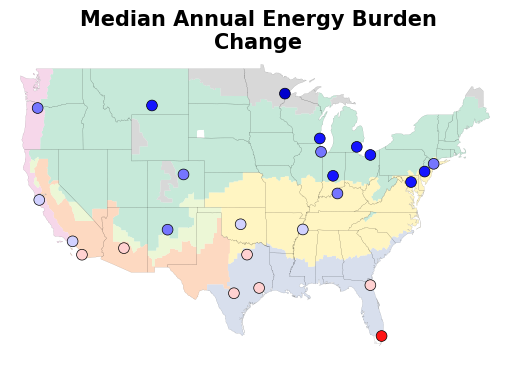

  State   City Building America Climate Zone  in.weather_file_latitude  \
6    FL  Miami                     Hot-Humid                     25.82   

   in.weather_file_longitude  Change in Energy Burden [Seasonal]  
6                      -80.3                            0.000496  
   State     City Building America Climate Zone  in.weather_file_latitude  \
11    MI  Detroit                          Cold                     42.22   

    in.weather_file_longitude  Change in Energy Burden [Seasonal]  
11                     -83.35                           -0.009817  


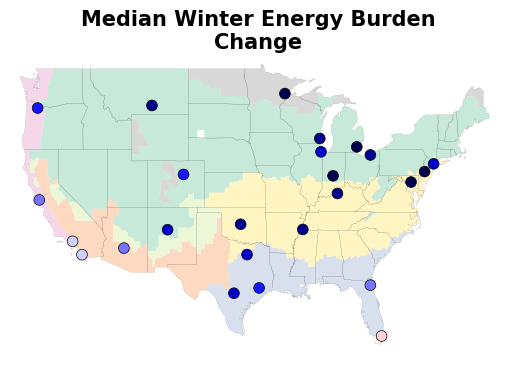

  State          City Building America Climate Zone  in.weather_file_latitude  \
5    FL  Jacksonville                     Hot-Humid                     30.23   

   in.weather_file_longitude  Change in Energy Burden [Seasonal]  
5                     -81.68                            0.006169  
   State      City Building America Climate Zone  in.weather_file_latitude  \
18    OR  Portland                        Marine                     45.59   

    in.weather_file_longitude  Change in Energy Burden [Seasonal]  
18                     -122.6                           -0.000584  


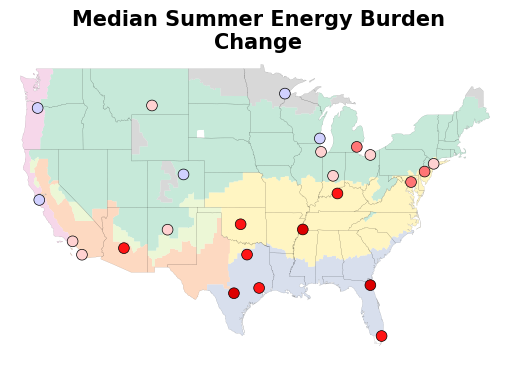

  State          City Building America Climate Zone  in.weather_file_latitude  \
5    FL  Jacksonville                     Hot-Humid                     30.23   

   in.weather_file_longitude  Change in Energy Burden [Seasonal]  
5                     -81.68                             0.00641  
   State    City Building America Climate Zone  in.weather_file_latitude  \
12    MN  Duluth                     Very Cold                     46.84   

    in.weather_file_longitude  Change in Energy Burden [Seasonal]  
12                     -92.19                            0.000093  


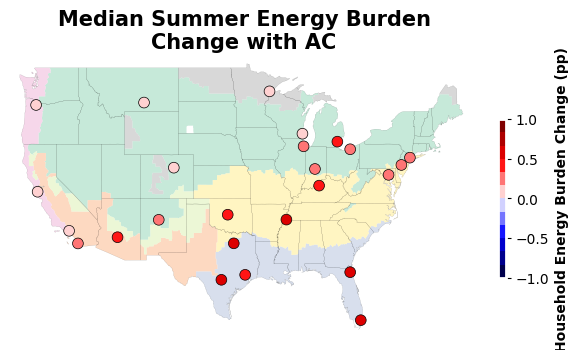

In [35]:
save = True 
save_dir = Path('/Users/camilotoruno/Downloads/')

group_by = ['State', 'City', 'Building America Climate Zone', 'in.weather_file_latitude', 'in.weather_file_longitude']

ann_warming_bin1 = annual_percentiles['CONUS Annual Climate Change Bins [Celsius]'] == '(1.5, 2.0]'
ann_percentile = annual_percentiles['Percentile'] == 0.5
# bin2 = annual_results['CONUS Annual Climate Change Bins [Celsius]'] == '(2.0, 2.5]'

seas_warming_bin1 = seasonal_percentiles['CONUS Annual Climate Change Bins [Celsius]'] == '(1.5, 2.0]'
seas_percentile = seasonal_percentiles['Percentile'] == 0.5
# seas_warming_bin2 = seas_res['CONUS Annual Climate Change Bins [Celsius]'] == '(2.0, 2.5]'

seas_winter = seasonal_percentiles['Season'] == 'Winter'
seas_summer = seasonal_percentiles['Season'] == 'Summer'

seas_ac = seasonal_percentiles['HVAC Cooling Type'] != '0'
annual_ac = annual_percentiles['HVAC Cooling Type'] != '0'
annual_heating = annual_percentiles['Heating Fuel'] != '0'
annual_hvac = annual_ac & annual_heating

results_dict = {}
hvac_energy_usage_change = {}   
total_energy_usage_change = {}
energy_burden_change = {}

energy_burden_change['Median Annual Energy Burden Change'] = annual_percentiles[ann_warming_bin1 & ann_percentile].groupby(group_by)['Change in Energy Burden [Annual]'].quantile(0.5).to_frame().reset_index()
# energy_burden_change['Median Annual Energy Burden Change for Households with HVAC'] = annual_percentiles[ann_warming_bin1 & ann_percentile & annual_hvac].groupby(group_by)['Change in Energy Burden [Annual]'].quantile(0.5).to_frame().reset_index()
energy_burden_change['Median Winter Energy Burden Change'] = seasonal_percentiles[seas_warming_bin1 & seas_winter & seas_percentile].groupby(group_by)['Change in Energy Burden [Seasonal]'].quantile(0.5).to_frame().reset_index()
energy_burden_change['Median Summer Energy Burden Change'] = seasonal_percentiles[seas_warming_bin1 & seas_summer & seas_percentile].groupby(group_by)['Change in Energy Burden [Seasonal]'].quantile(0.5).to_frame().reset_index()
energy_burden_change['Median Summer Energy Burden Change with AC'] = seasonal_percentiles[seas_warming_bin1 & seas_summer & seas_ac & seas_percentile].groupby(group_by)['Change in Energy Burden [Seasonal]'].quantile(0.5).to_frame().reset_index()
energy_burden_change['abs_max'] = find_abs_max(df_dictionary = energy_burden_change, col_name_fragment = 'Change in Energy Burden')

hvac_energy_usage_change['Median Annual Heating & Cooling Percent Change'] = annual_percentiles[ann_warming_bin1 & ann_percentile].groupby(group_by)['Percent Change in Total Energy Usage:Space Conditioning [kWh](Annual)'].quantile(0.5).to_frame().reset_index()
hvac_energy_usage_change['Median Winter Heating & Cooling Percent Change'] = seasonal_percentiles[seas_warming_bin1 & seas_winter & seas_percentile].groupby(group_by)['Percent Change in Total Energy Usage:Space Conditioning [kWh](Seasonal)'].quantile(0.5).to_frame().reset_index()
hvac_energy_usage_change['Median Summer Heating & Cooling Percent Change'] = seasonal_percentiles[seas_warming_bin1 & seas_summer & seas_percentile].groupby(group_by)['Percent Change in Total Energy Usage:Space Conditioning [kWh](Seasonal)'].quantile(0.5).to_frame().reset_index()
hvac_energy_usage_change['Median Summer Heating & Cooling Percent Change with AC'] = seasonal_percentiles[seas_warming_bin1 & seas_summer & seas_ac & seas_percentile].groupby(group_by)['Percent Change in Total Energy Usage:Space Conditioning [kWh](Seasonal)'].quantile(0.5).to_frame().reset_index()
hvac_energy_usage_change['abs_max'] = find_abs_max(df_dictionary = hvac_energy_usage_change, col_name_fragment = 'Percent Change in Total Energy Usage:Space Conditioning')

total_energy_usage_change['Median Annual Total Energy Percent Change'] = annual_percentiles[ann_warming_bin1 & ann_percentile].groupby(group_by)['Percent Change in Total Energy Usage:Facility [kWh](Annual)'].quantile(0.5).to_frame().reset_index()
total_energy_usage_change['Median Winter Total Energy Percent Change'] = seasonal_percentiles[seas_warming_bin1 & seas_winter & seas_percentile].groupby(group_by)['Percent Change in Total Energy Usage:Facility [kWh](Seasonal)'].quantile(0.5).to_frame().reset_index()
total_energy_usage_change['Median Summer Total Energy Percent Change'] = seasonal_percentiles[seas_warming_bin1 & seas_summer & seas_percentile].groupby(group_by)['Percent Change in Total Energy Usage:Facility [kWh](Seasonal)'].quantile(0.5).to_frame().reset_index()
total_energy_usage_change['Median Summer Total Energy Percent Change with AC'] = seasonal_percentiles[seas_warming_bin1 & seas_summer & seas_ac & seas_percentile].groupby(group_by)['Percent Change in Total Energy Usage:Facility [kWh](Seasonal)'].quantile(0.5).to_frame().reset_index()
total_energy_usage_change['abs_max'] = find_abs_max(df_dictionary = total_energy_usage_change, col_name_fragment = 'Percent Change in Total Energy Usage:Facility')

# energy_burden_change['Median Annual Percent Energy Burden Change'] = annual_percentiles[ann_warming_bin1 & ann_percentile].groupby(group_by)['Percent Change in Energy Burden [Annual]'].quantile(0.5).to_frame().reset_index()
# energy_burden_change['Median Winter Percent Energy Burden Change'] = seasonal_percentiles[seas_warming_bin1 & seas_winter & seas_percentile].groupby(group_by)['Percent Change in Energy Burden [Seasonal]'].quantile(0.5).to_frame().reset_index()
# energy_burden_change['Median Summer Percent Energy Burden Change'] = seasonal_percentiles[seas_warming_bin1 & seas_summer & seas_percentile].groupby(group_by)['Percent Change in Energy Burden [Seasonal]'].quantile(0.5).to_frame().reset_index()
# energy_burden_change['Median Summer Percent Energy Burden Change with AC'] = seasonal_percentiles[seas_warming_bin1 & seas_summer & seas_ac & seas_percentile].groupby(group_by)['Percent Change in Energy Burden [Seasonal]'].quantile(0.5).to_frame().reset_index()
# energy_burden_change['abs_max'] = find_abs_max(df_dictionary = energy_burden_change, col_name_fragment = 'Percent Change in Energy Burden')
# plot_df_dictionary(dictionary = energy_burden_change, col_name_fragment = 'Percent Change in Energy Burden', label = "Change in Household Energy Burden (pp)", save = save, cbar = False)

energy_burden_change['abs_max'] = 0.01 

plot_df_dictionary(dictionary = energy_burden_change, col_name_fragment = 'Change in Energy Burden', label = "Household Energy Burden Change (pp)", save = save, cbar = False, save_dir = save_dir)
# plot_df_dictionary(dictionary = hvac_energy_usage_change, col_name_fragment = 'Percent Change in Total Energy Usage:Space Conditioning', label = "Change in Total Heating & Cooling Energy Usage (%)", save = save, cbar = False)
# plot_df_dictionary(dictionary = total_energy_usage_change, col_name_fragment = 'Percent Change in Total Energy Usage:Facility', label = "Change in Total Total Energy Usage (%)", save = save, cbar = False)

nrg_burdens_change_table = tabulate(energy_burden_change, partial_data_col_name='Change in Energy Burden', col_suffix=' [pp]')
hvac_energy_per_change_table = tabulate(hvac_energy_usage_change, partial_data_col_name='Percent Change in Total Energy Usage:Space Conditioning', col_suffix='')
total_energy_usage_change_table = tabulate(total_energy_usage_change, partial_data_col_name='Percent Change in Total Energy Usage:Facility ', col_suffix='')

# nrg_burdens_change_table.to_csv(Path('/Users/camilotoruno/Downloads/energy_burden_changes_table.csv'), index=False)
# hvac_energy_per_change_table.to_csv(Path('/Users/camilotoruno/Downloads/hvac_energy_usage_changes_table.csv'), index=False)
# total_energy_usage_change_table.to_csv(Path('/Users/camilotoruno/Downloads/total_energy_usage_changes_table.csv'), index=False)


In [9]:
energy_burden_change['abs_max']

0.009816710193898598

# Calculate energy burden exceedance 
Exceedance is the percentage of months where each building per climate change bin exceed some threshold values

### From chronological differences

In [11]:
metadata_cols_2 = ['bldg_id',
            'Year',
            'Month',
            'Climate Change Scenario',
            'ASHRAE IECC Climate Zone 2004',
            'Building America Climate Zone',
            'City',
            'in.cooling_setpoint',
            'Federal Poverty Level',
            'in.geometry_building_type_acs',
            'RECS Building Type',
            'in.geometry_stories',
            'in.geometry_wall_type',
            'Heating Fuel',
            'in.hvac_heating_type',
            'in.heating_setpoint',
            'in.hvac_cooling_efficiency',
            'in.hvac_cooling_partial_space_conditioning',
            'HVAC Cooling Type',
            'in.hvac_has_shared_system',
            'in.hvac_heating_efficiency',
            'Income',
            'Infiltration',
            'in.occupants',
            'State',
            'in.tenure',
            'in.vacancy_status',
            'in.vintage_acs',
            'in.weather_file_latitude',
            'in.weather_file_longitude',
            'in.windows',
            'Season',
            'CONUS Annual Climate Change Bins [Celsius]',
]

threshold_value_1 = 0.06   # nrg burden threshold
threshold_value_2 = 0.1    # nrg burden threshold

group_by_cols = ['bldg_id', 'CONUS Annual Climate Change Bins [Celsius]', 'Season']

energy_burden_exceedance = calculate_nrg_burden_exceedance_percentage(simulation_results, threshold_value_1, threshold_value_2, group_by_cols)
energy_burden_exceedance = join_metadata(df = energy_burden_exceedance, metadata= simulation_results[metadata_cols_2], data_col_check= '6pp Exceedance', on_and_groupby_cols= group_by_cols)

### From differences of percentiles

# Save results for analysis tables

In [13]:
# seasonal_percentiles.to_csv(Path('/Users/camilotoruno/Downloads/seasonal_percentiles.csv'), index=False)
# seasonal_nrg_burden_change_percentiles.to_csv(Path('/Users/camilotoruno/Downloads/seasonal_nrg_burden_change_percentiles.csv'), index=False)

# annual_results.to_csv(Path('/Users/camilotoruno/Downloads/annual_results.csv'), index=False)
# seas_res.to_csv(Path('/Users/camilotoruno/Downloads/seasonal_results-4.csv'), index=False)

# energy_burden_exceedance.to_csv(Path('/Users/camilotoruno/Downloads/energy_burden_exceedance-5.csv'), index=False)

seasonal_percentiles.to_csv(Path('/Users/camilotoruno/Downloads/seasonal_percentiles.csv'), index=False)
annual_percentiles.to_csv(Path('/Users/camilotoruno/Downloads/annual_percentiles.csv'), index=False)


# Attempt to do some box plots in Python rather than JMP
Finding that I'm having a hard to generating plots that look how I want with Plotly. Consider switching to R or MATLAB for better plotting if JMP undesired.

In [83]:
import plotly.graph_objects as go


ann_historical = annual_percentiles['CONUS Annual Climate Change Bins [Celsius]'] == 'Historical'
ann_hvac = (annual_percentiles['HVAC Cooling Type'] != '0') & (annual_percentiles['Heating Fuel'] != '0')
df = annual_percentiles[ann_historical & ann_hvac].copy(deep=True)
df['Energy Burden [Annual]'] = df['Energy Burden [Annual]']*100

fig = go.Figure()

fig.add_trace(go.Violin(x=df['Building America Climate Zone'][ df['Percentile'] == 0.1 ],
                        y=df['Energy Burden [Annual]'][ df['Percentile'] == 0.1 ],
                        legendgroup='10th', scalegroup='10th', name='10th Percentile',
                        points=False,
                        # line_color='lightseagreen'
                        )
             )
fig.add_trace(go.Violin(x=df['Building America Climate Zone'][ df['Percentile'] == 0.5 ],
                        y=df['Energy Burden [Annual]'][ df['Percentile'] == 0.5 ],
                        legendgroup='50th', scalegroup='50th', name='50th Percentile',
                        points=False,
                        # line_color='orange'
                        )
             )
fig.add_trace(go.Violin(x=df['Building America Climate Zone'][ df['Percentile'] == 0.9 ],
                        y=df['Energy Burden [Annual]'][ df['Percentile'] == 0.9 ],
                        legendgroup='90th', scalegroup='90th', name='90th Percentile',
                        points=False,
                        # line_color='orange'
                        )
             )

fig.update_layout(violinmode='group', 
                title_text="Historical Annual Energy Burden for Households with HVAC",
                title_x = 0.5, 
                yaxis=dict(
                    ticksuffix="%"
                    ),
                legend=dict(
                    orientation="h",
                    entrywidth=90,
                    yanchor="bottom",
                    y=-0.25,
                    xanchor="center",
                    x=0.5)
                )

fig.update_traces(box_visible=True, meanline_visible=True, box_width= 1)
fig.update_traces(opacity=0.65, selector=dict(type='violin'))

fig.update_yaxes(range=[-5, 50])
fig.add_hline(y=10, line_width=2, line_dash="dash", line_color="red")
fig.add_hline(y=6, line_width=2, line_dash="dash", line_color="tomato")
fig.show()

In [84]:
annual_percentiles['CONUS Annual Climate Change Bins [Celsius]'].unique()

array(['(1.5, 2.0]', '(2.0, 2.5]', 'Historical'], dtype=object)

In [109]:


ann_historical = annual_percentiles['CONUS Annual Climate Change Bins [Celsius]'] == '(1.5, 2.0]'
ann_hvac = (annual_percentiles['HVAC Cooling Type'] != '0') & (annual_percentiles['Heating Fuel'] != '0')
df = annual_percentiles[ann_historical & ann_hvac].copy(deep=True)

df['Change in Energy Burden [Annual]'] = df['Change in Energy Burden [Annual]']*100

fig = go.Figure()

fig.add_trace(go.Violin(x=df['Building America Climate Zone'][ df['Percentile'] == 0.1 ],
                        y=df['Change in Energy Burden [Annual]'][ df['Percentile'] == 0.1 ],
                        legendgroup='10th', scalegroup='10th', name='10th Percentile',
                        points=False,
                        # line_color='lightseagreen'
                        )
             )
fig.add_trace(go.Violin(x=df['Building America Climate Zone'][ df['Percentile'] == 0.5 ],
                        y=df['Change in Energy Burden [Annual]'][ df['Percentile'] == 0.5 ],
                        legendgroup='50th', scalegroup='50th', name='50th Percentile',
                        points=False,
                        # line_color='orange'
                        )
             )
fig.add_trace(go.Violin(x=df['Building America Climate Zone'][ df['Percentile'] == 0.9 ],
                        y=df['Change in Energy Burden [Annual]'][ df['Percentile'] == 0.9 ],
                        legendgroup='90th', scalegroup='90th', name='90th Percentile',
                        points=False,
                        # line_color='orange'
                        )
             )

fig.update_layout(violinmode='group', 
                title_text="Midcentury Annual Change in Energy Burden for Households with HVAC",
                title_x = 0.5, 
                yaxis=dict(
                    ticksuffix="pp"
                    ),
                legend=dict(
                    orientation="h",
                    entrywidth=90,
                    yanchor="bottom",
                    y=-0.25,
                    xanchor="center",
                    x=0.5)
                )

fig.update_traces(box_visible=True, meanline_visible=True, box_width= 1)
fig.update_traces(opacity=0.65, selector=dict(type='violin'))
fig.update_yaxes(range=[-2, 2], minor=dict(tickcolor="black", tickmode='auto', nticks=6, showgrid=True))

fig.add_hline(y=0, line_width=2, line_dash="dash", line_color="black")
fig.show()

# Do some analysis of the buildstock sample characteristics

In [ ]:
buildstock = pd.read_csv(Path("/Users/camilotoruno/My Drive/Knowledge & Skills/UMichigan/Research/Energy Burdens/Data & analysis/analysis 24.08.12/buildstock.csv"))
full_buildstock = pd.read_csv(Path("/Users/camilotoruno/Documents/GitHub/building_energy_modeling/baseline_metadata_only.csv"))

/var/folders/_y/4mxb3fn133zdycdh3jhdzvc00000gn/T/ipykernel_59915/4135891642.py:4: DtypeWarning: Columns (61,113,121) have mixed types. Specify dtype option on import or set low_memory=False.
  full_buildstock = pd.read_csv(Path("/Users/camilotoruno/Documents/GitHub/building_energy_modeling/baseline_metadata_only.csv"))


548916
57955


In [36]:
city_list = buildstock['in.city'].unique()
full_buildstock = full_buildstock[ full_buildstock['in.city'].isin(city_list) ]

sample_counts = buildstock['in.city'].value_counts().reset_index()
full_counts = full_buildstock['in.city'].value_counts().reset_index()

table = pd.merge(sample_counts, full_counts, on= 'in.city', suffixes=['_sample', '_databaseTotal'])
table['Max Sample Size'] = table['count_databaseTotal'].apply(lambda x: min(800, x))
table['Inferred FPL Percentage'] = (table['count_sample']/table['Max Sample Size']).round(2)

# City	Sample Count	Database Count	Max Sample Size	Inferred FPL Percentage
col_renaming = {'in.city': 'City', 
          'count_sample': 'Sample Count',
          'count_databaseTotal': 'Database Count',          
          }

table.rename(columns = col_renaming, inplace=True)
print('Max Sample Size for cities exceeding 800 total houses', table[table['Database Count'] > 800]['Sample Count'].max())
print('Min Sample Size for cities exceeding 800 total houses', table[table['Database Count'] > 800]['Sample Count'].min())

print(len(table[table['Database Count'] > 800]))

Max Sample Size for cities exceeding 800 total houses 462
Min Sample Size for cities exceeding 800 total houses 149
22


In [ ]:
table.to_csv(Path("/Users/camilotoruno/My Drive/Knowledge & Skills/UMichigan/Research/Energy Burdens/Data & analysis/analysis 24.08.12/buildstock_sample_counts.csv"), index=False)